<a href="https://colab.research.google.com/github/GiridurgaG/WorkBook/blob/main/Mobile_Price_Range_Prediction(ML_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Mobile Price Range Prediction(ML Classification)



##### **Project Type**    - ML Classification
##### **Contribution**    - Individual
##### **Name**            - Giridurga G P

# **Project Summary -**

In today's fast-paced digital world, smartphones have become an essential part of everyday life. With so many options available, ranging from basic budget phones to premium flagship devices, understanding what factors influence a phone's price is not just useful for manufacturers but also for consumers, retailers, and online platforms. This project focuses on predicting the price range of mobile phones based on their technical specifications using machine learning.

The goal of this project is to build a reliable classification model that can categorize mobile phones into four distinct price segments: Low Cost, Medium Cost, High Cost, and Very High Cost. The dataset contains various key specifications of mobile devices, such as battery power, RAM, screen size, processor speed, storage capacity, and camera features. These are all factors that consumers often consider before making a purchase, and they also have a direct impact on the product's price.

The project starts with thorough Exploratory Data Analysis (EDA) to understand the data better. During this phase, meaningful visualizations such as histograms, boxplots, scatterplots, and heatmaps help reveal patterns and relationships within the data. For example, we explore how features like RAM size or battery capacity correlate with the price range. This helps to not only clean and prepare the data but also to gain insights into which specifications matter the most when determining a phone's price.

Once the data is prepared, several machine learning models are applied to predict the price range. These include popular classification algorithms such as Logistic Regression, Decision Trees, Random Forest, and advanced ensemble techniques like XGBoost. Each model's performance is evaluated using metrics like Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix to ensure we're not just building a model that works for this dataset, but one that can generalize well to new, unseen data.

To further improve the model's performance, hyperparameter tuning is performed using methods like Grid Search and Randomized Search. Cross-validation techniques are also applied to make sure the model is stable and not overfitting to the training data. Through these iterations, models like Random Forest and XGBoost typically emerge as top performers, thanks to their ability to handle complex relationships and provide feature importance rankings.

One of the key outcomes of this project is identifying the most influential features that affect mobile pricing. Unsurprisingly, specifications like RAM size, battery power, and internal storage stand out as major contributors. These insights can be invaluable for mobile phone manufacturers and sellers. For businesses, being able to predict price ranges accurately means they can target the right market segments, optimize pricing strategies, manage inventory more effectively, and improve product recommendations for customers.

In short, this project demonstrates how machine learning can help bridge the gap between technical product specifications and real-world pricing decisions. By accurately predicting the price range of mobile phones, companies can stay competitive, while consumers get products that better match their needs and budget. It's a practical example of how data-driven approaches can create value across the technology and retail industries.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The goal of this project is to build a machine learning classification model that predicts the price range of mobile phones based on their technical specifications, such as RAM, battery power, storage, and screen size. The price is categorized into four ranges: Low, Medium, High, and Very High. Accurate price range prediction will help manufacturers, retailers, and e-commerce platforms with better pricing, product positioning, and customer targeting, making the decision-making process more data-driven and efficient.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from datetime import datetime

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier

### Dataset Loading

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/data_mobile_price_range.csv')

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df.shape

(2000, 21)

### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


<Axes: >

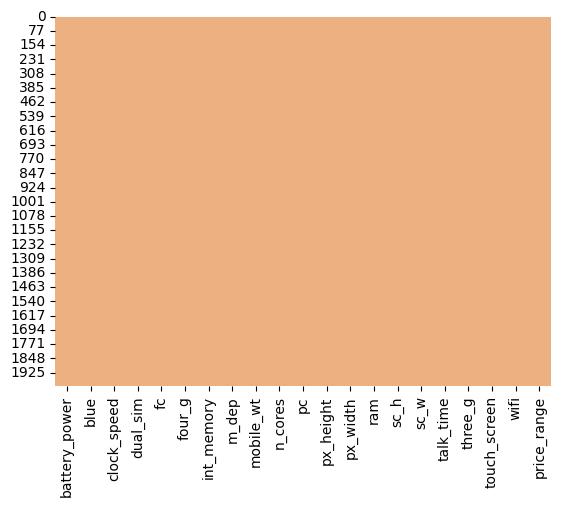

In [9]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cmap = 'flare', cbar=False)

### What did you know about your dataset?

*   This dataset contains 2000 rows with 21 columns.
*   No duplicate values present.
*   No missing values present.
*   It has all numerical columns.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [11]:
# Dataset Describe
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


### Variables Description

Battery_power - Total energy a battery can store in one time measured in mAh.

Blue - Has bluetooth or not.

Clock_speed - speed at which microprocessor executes instructions.

Dual_sim - Has dual sim support or not.

Fc - Front Camera mega pixels.

Four_g - Has 4G or not.

Int_memory - Internal Memory in Gigabytes.

M_dep - Mobile Depth in cm.

Mobile_wt - Weight of mobile phone.

N_cores - Number of cores of processor.

Pc - Primary Camera mega pixels.

Px_height - Pixel Resolution Height.

Px_width - Pixel Resolution Width.

Ram - Random Access Memory in Mega.

Touch_screen - Has touch screen or not.

Wifi - Has wifi or not.

Sc_h - Screen Height of mobile in cm.

Sc_w - Screen Width of mobile in cm.

Talk_time - longest period a fully charged battery will last when used for voice calls only.

Three_g - Has 3G or not.

Wifi - Has wifi or not.

Price_range - This is the target variable with value of
0(low cost), 1(medium cost),2(High Cost),3(Very High cost).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("no. of unique values in",i,"is", df[i].nunique())

no. of unique values in battery_power is 1094
no. of unique values in blue is 2
no. of unique values in clock_speed is 26
no. of unique values in dual_sim is 2
no. of unique values in fc is 20
no. of unique values in four_g is 2
no. of unique values in int_memory is 63
no. of unique values in m_dep is 10
no. of unique values in mobile_wt is 121
no. of unique values in n_cores is 8
no. of unique values in pc is 21
no. of unique values in px_height is 1137
no. of unique values in px_width is 1109
no. of unique values in ram is 1562
no. of unique values in sc_h is 15
no. of unique values in sc_w is 19
no. of unique values in talk_time is 19
no. of unique values in three_g is 2
no. of unique values in touch_screen is 2
no. of unique values in wifi is 2
no. of unique values in price_range is 4


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

zero_counts = (df == 0).sum()

# Display columns with zero values
zero_counts = zero_counts[zero_counts > 0]
print(zero_counts)

blue            1010
dual_sim         981
fc               474
four_g           957
pc               101
px_height          2
sc_w             180
three_g          477
touch_screen     994
wifi             986
price_range      500
dtype: int64


In [14]:
# Calculate mean
px_height_mean = df['px_height'].mean()
sc_w_mean = df['sc_w'].mean()

# Fill 0's with mean
df['px_height'].fillna(px_height_mean, inplace=True)
df['sc_w'].fillna(sc_w_mean, inplace=True)

In [15]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### What all manipulations have you done and insights you found?

*   Checked what all columns contains 0 as values.
*   Among them, px_height and sc_w shouldn't be 0.
*   So the 0 values are replaced with the mean values.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

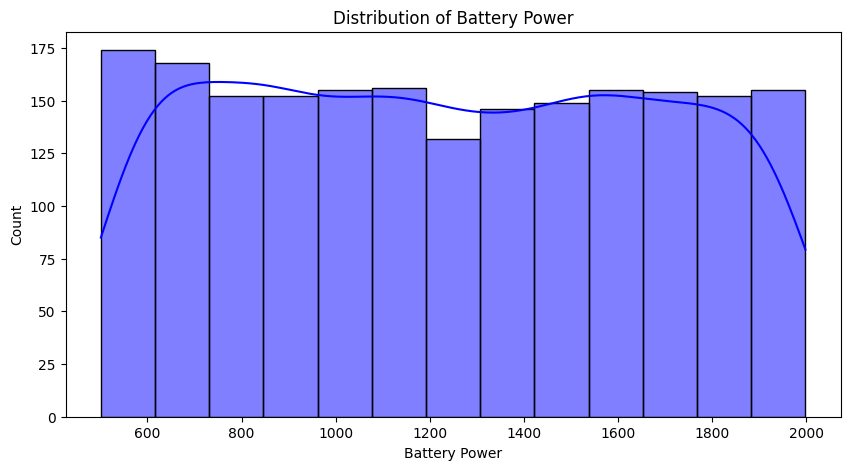

In [16]:
# Chart - 1 visualization code
plt.figure(figsize=(10,5))
sns.histplot(df["battery_power"], kde=True, color='b')
plt.title("Distribution of Battery Power")
plt.xlabel("Battery Power")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

The histogram with a density curve was chosen to visualize the distribution of the Battery Power feature in the dataset. Combining the histogram with a smooth density line gives both frequency and distribution shape, making it easier to interpret the data's behavior.

##### 2. What is/are the insight(s) found from the chart?

The battery power values are relatively well distributed between 500 mAh and 2000 mAh, covering a broad range of devices.

There is a slight concentration of devices with battery power around 600-700 mAh and another around 1500-1600 mAh, indicating common design preferences in the market.

The density curve shows slight fluctuations, suggesting that while battery capacities vary, manufacturers tend to release devices with popular battery sizes that consumers demand.

There are no extreme spikes or outliers, implying that battery power values are evenly represented across different devices

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:

Understanding the battery power distribution helps manufacturers target popular battery capacities (around 600-700 mAh and 1500-1600 mAh) to align with market expectations.

Retailers can stock devices across the battery range, ensuring they meet the needs of both low-end and high-end market segments.

Negative Insights:

If a company focuses solely on extreme battery capacities (either very low or very high) without addressing the mid-range preferences, they risk missing a significant portion of the market where most competition exists.

Devices with battery power below 600 mAh or above 2000 mAh may fall outside mainstream demand, leading to potential overproduction or poor sales in those segments.

#### Chart - 2

In [17]:
# Has bluetooth or not
df['blue'].value_counts()

,count
blue,
0,1010
1,990


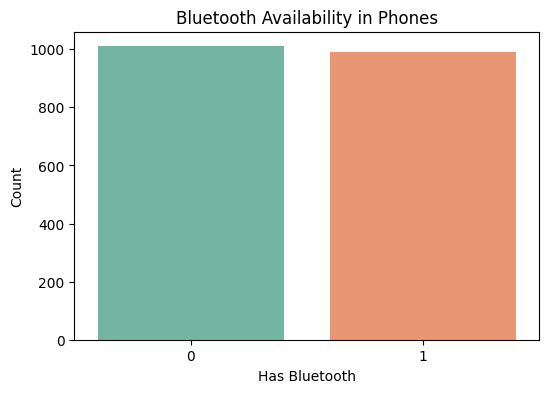

In [18]:
# Chart - 2 visualization code
plt.figure(figsize=(6, 4))
sns.countplot(x='blue', data=df, palette='Set2')
plt.title('Bluetooth Availability in Phones')
plt.xlabel('Has Bluetooth')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to visualize the distribution of Bluetooth availability as it's a binary categorical feature (0 = No Bluetooth, 1 = Has Bluetooth). Bar charts are ideal for comparing counts of categorical variables and give a quick visual comparison of how many phones have or lack Bluetooth functionality.

##### 2. What is/are the insight(s) found from the chart?

The dataset shows an almost equal distribution between phones that have Bluetooth and those that do not.

Approximately 50% of the phones in the dataset offer Bluetooth functionality, indicating that Bluetooth is not yet a universal feature across all devices in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:

Manufacturers can assess market trends: If Bluetooth is present in nearly half of the devices, it suggests that offering Bluetooth is becoming standard, especially for devices targeting mid-to-high price segments.

Product development teams can analyze whether incorporating Bluetooth adds value or serves as a differentiator, particularly in low-cost devices where it might not yet be standard.

Marketers can target Bluetooth-enabled devices to consumers interested in wireless accessories, improving upselling opportunities (e.g., wireless earphones, smartwatches).

Negative Insights:

If companies overlook the trend toward Bluetooth adoption and continue to release devices without it, they may lose competitiveness, especially as more consumers expect wireless connectivity even in budget segments.

#### Chart - 3

In [19]:
# Group by price_range and dual_sim
df.groupby(['price_range', 'dual_sim']).size().unstack()

dual_sim,0,1
price_range,,
0,250,250
1,245,255
2,251,249
3,235,265


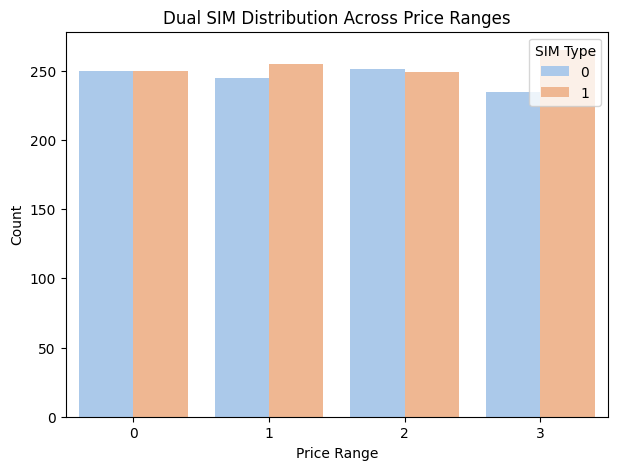

In [20]:
# Chart - 3 visualization code
plt.figure(figsize=(7, 5))
sns.countplot(x='price_range', hue='dual_sim', data=df, palette='pastel')
plt.title('Dual SIM Distribution Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.legend(title='SIM Type')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart clearly shows the comparison of Single vs Dual SIM availability across different price ranges.

##### 2. What is/are the insight(s) found from the chart?

Dual SIM phones are evenly distributed across all price segments.

Both low-cost and premium devices offer Single and Dual SIM options.

Premium phones still include Single SIM models, likely based on market demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Offering Dual SIM in all price ranges can meet diverse consumer needs.

Brands can launch both Single and Dual SIM variants to widen market reach.

Negative Impact:

Ignoring Dual SIM demand in regions where it's popular may lead to missed sales.

#### Chart - 4

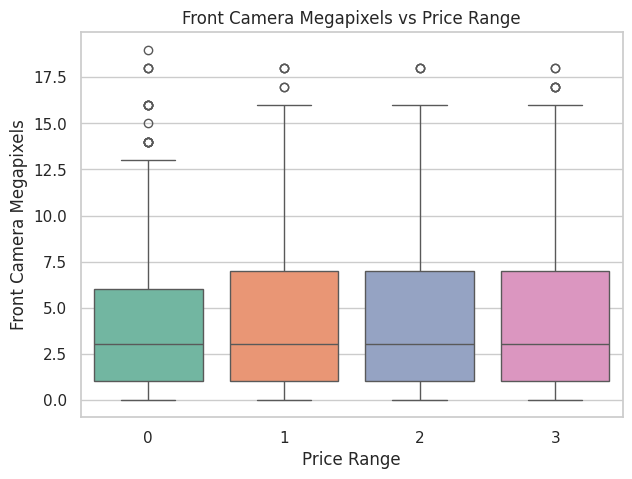

In [21]:
# Chart - 4 visualization code
sns.set(style="whitegrid")

plt.figure(figsize=(7, 5))
sns.boxplot(x='price_range', y='fc', data=df, palette='Set2')

plt.xlabel('Price Range')
plt.ylabel('Front Camera Megapixels')
plt.title('Front Camera Megapixels vs Price Range')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot shows the distribution and variation of front camera megapixels across different price ranges, highlighting medians, spread, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Median front camera quality increases slightly with price, but the difference is minimal.

All price segments show wide variation and outliers with some phones offering high megapixels, even in lower price ranges.

Higher megapixels don't strictly correlate with higher price, indicating other specs may drive pricing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Budget phones offering decent front cameras can attract price-sensitive, selfie-focused customers.

High-end phones should differentiate with features beyond just front camera megapixels.

Negative Impact:

Over-relying on front camera specs alone may not justify higher pricing.

#### Chart - 5

In [22]:
# Group and count phones by price range and 4G support
df.groupby(['price_range', 'four_g']).size().unstack()

four_g,0,1
price_range,,
0,241,259
1,238,262
2,253,247
3,225,275


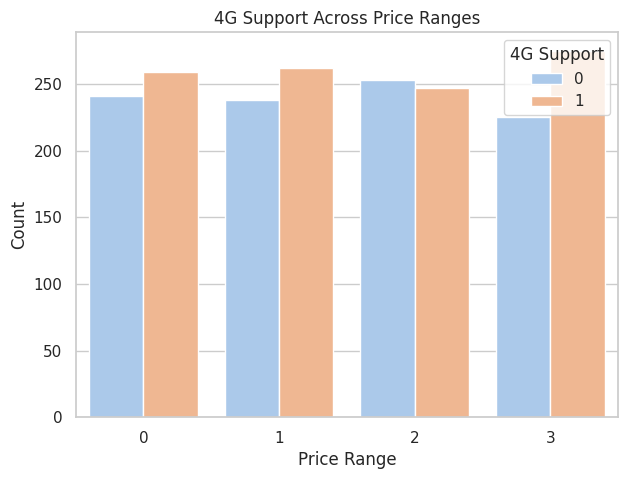

In [23]:
# Chart - 5 visualization code

plt.figure(figsize=(7, 5))
sns.countplot(x='price_range', hue='four_g', data=df, palette='pastel')
plt.title('4G Support Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.legend(title='4G Support')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart clearly compares the count of phones with and without 4G support across different price ranges.

##### 2. What is/are the insight(s) found from the chart?

4G-supported phones are present in all price segments, including budget models.

In lower price ranges (0 & 1), 4G phones slightly outnumber non-4G models.

In higher price ranges (2 & 3), the distribution is balanced, but 4G support remains common.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Growing 4G presence even in budget phones shows market demand for better connectivity.

Manufacturers should ensure 4G availability in all segments to stay competitive.

Negative Impact:

Ignoring 4G in low-cost models may reduce market share, especially in regions with widespread 4G networks.

#### Chart - 6

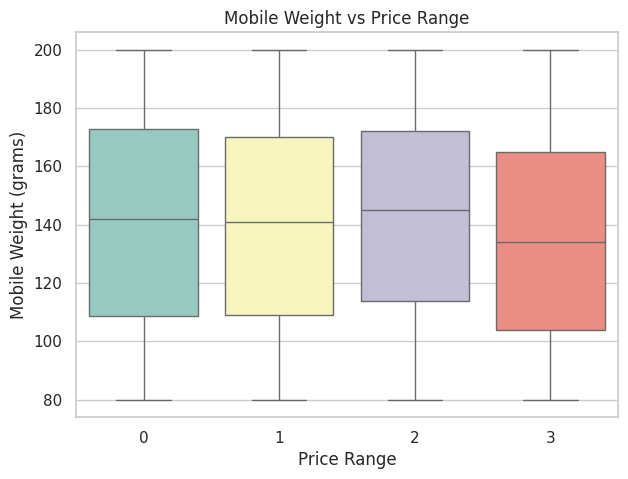

In [24]:
# Chart - 6 visualization code
plt.figure(figsize=(7, 5))
sns.boxplot(x='price_range', y='mobile_wt', data=df, palette='Set3')

plt.xlabel('Price Range')
plt.ylabel('Mobile Weight (grams)')
plt.title('Mobile Weight vs Price Range')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot effectively shows how mobile weight varies across price ranges, highlighting medians, spread, and any extreme values.

##### 2. What is/are the insight(s) found from the chart?

Median mobile weight stays fairly consistent across all price ranges (around 130-145 grams).

Higher-priced phones are not significantly heavier or lighter than low-cost ones.

The weight range (80g to 200g) is similar across segments, suggesting weight isn't a strong price indicator.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Manufacturers can design lightweight phones in all price categories to attract users valuing portability.

Premium devices don't need to rely on weight to signal quality—other features are more impactful.

Negative Impact:

Overly heavy devices may discourage buyers, but extreme variations are minimal here.

#### Chart - 7

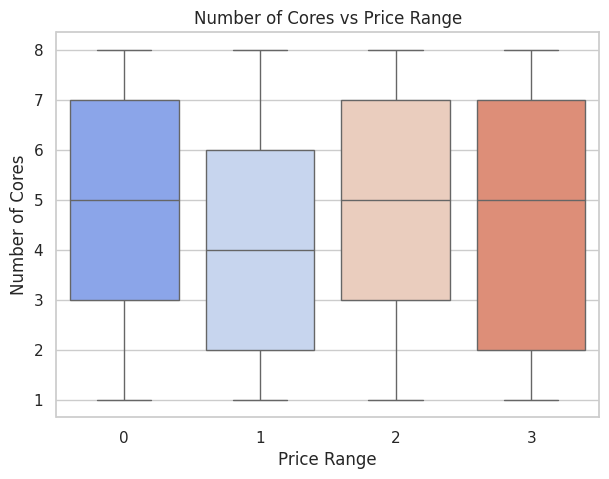

In [25]:
# Chart - 7 visualization code
plt.figure(figsize=(7, 5))
sns.boxplot(x='price_range', y='n_cores', data=df, palette='coolwarm')

plt.xlabel('Price Range')
plt.ylabel('Number of Cores')
plt.title('Number of Cores vs Price Range')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot helps visualize how the number of processor cores varies across different price segments, highlighting medians and data spread.

##### 2. What is/are the insight(s) found from the chart?

Median core count is fairly similar across all price ranges (around 4 to 5 cores).

Even low-cost phones can have up to 8 cores, suggesting core count alone doesn't define price.

Wide variation exists in every price segment, indicating other features influence pricing more heavily.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Consumers can access multi-core performance even in budget phones.

Brands should market additional features beyond cores to justify higher prices.

Negative Impact:

Relying only on core count to price phones may not align with market expectations.

#### Chart - 8

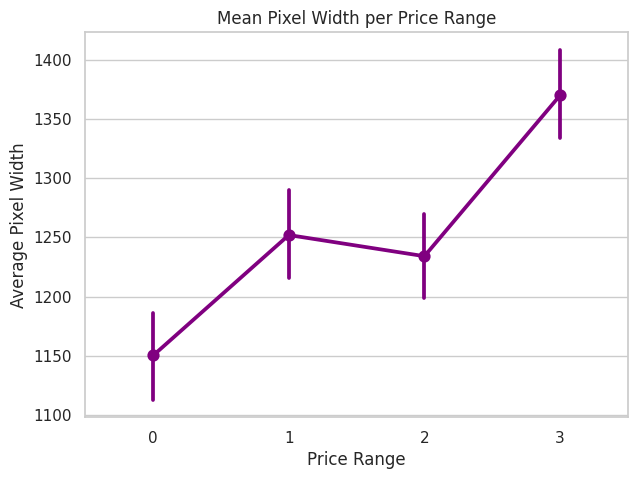

In [26]:
# Chart - 8 visualization code
plt.figure(figsize=(7, 5))
sns.pointplot(x='price_range', y='px_width', data=df, color='purple')
plt.title('Mean Pixel Width per Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Pixel Width')
plt.show()

##### 1. Why did you pick the specific chart?

A line plot shows how average screen pixel width changes across different price segments, highlighting trends and variation.

##### 2. What is/are the insight(s) found from the chart?

Pixel width increases with price, especially for high-end phones (Price Range 3).

Mid-range phones (Price Range 1 & 2) show slight variation but generally higher pixel width than budget models.

Higher resolution is clearly associated with premium devices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Premium devices emphasize better display quality, which can justify higher pricing.

Brands can improve screen resolution in mid-range phones to attract more buyers.

Negative Impact:

Low pixel width in budget devices is expected but brands should ensure it's competitive within the segment.

#### Chart - 9

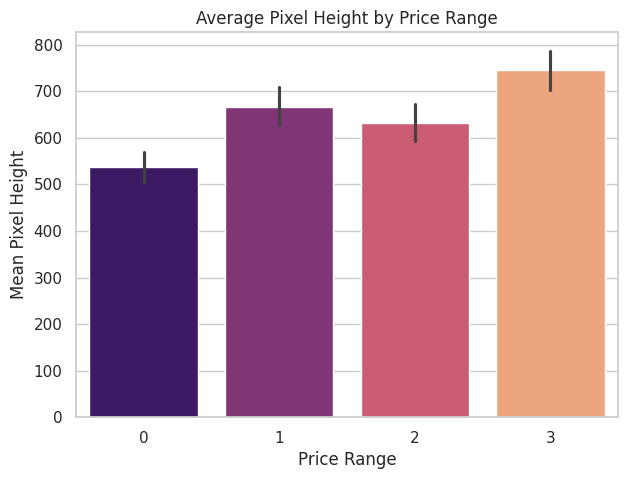

In [27]:
# Chart - 9 visualization code
plt.figure(figsize=(7, 5))
sns.barplot(x='price_range', y='px_height', data=df, estimator='mean', palette='magma')
plt.title('Average Pixel Height by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Mean Pixel Height')
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot effectively compares the average screen pixel height across price ranges, showing trends and variability.

##### 2. What is/are the insight(s) found from the chart?

Pixel height increases with price, highest in premium devices (Price Range 3).

Budget phones (Price Range 0) have noticeably lower resolution.

Mid-range phones improve on display but still vary slightly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High pixel height adds value to premium devices, enhancing display quality.

Boosting resolution in mid-range phones can help brands stay competitive.

Poor display quality in budget devices may reduce appeal, but keeping costs low is key.

#### Chart - 10

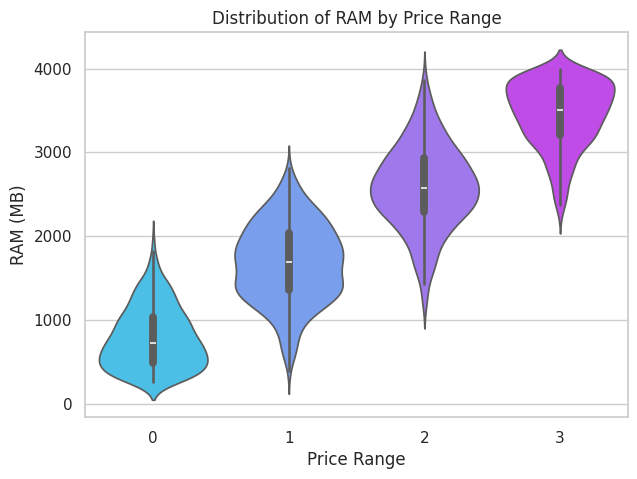

In [28]:
# Chart - 10 visualization code
plt.figure(figsize=(7, 5))
sns.violinplot(x='price_range', y='ram', data=df, palette='cool')
plt.title('Distribution of RAM by Price Range')
plt.xlabel('Price Range')
plt.ylabel('RAM (MB)')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a violin plot to visualize the distribution of RAM across the four price ranges because it shows the spread, density, and central tendency of RAM values in each price segment.

##### 2. What is/are the insight(s) found from the chart?

There is a clear, consistent increase in RAM as the price range moves from 0 (low) to 3 (very high).

The distributions shift upward with higher price ranges, indicating that RAM is a strong differentiator: low-cost phones cluster around low RAM, while high-cost phones consistently have higher RAM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes.

Invest in increasing RAM for models targeting higher price segments.

Confidently position devices with higher RAM in higher price brackets, aligning product specs with customer expectations.

No, there are no negative-growth insights.

#### Chart - 11

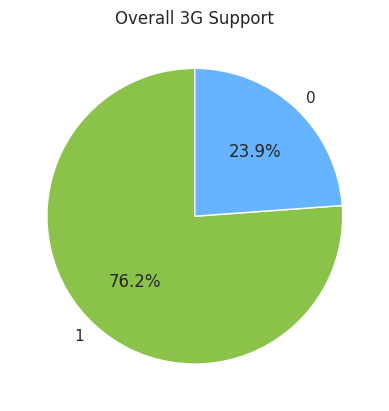

In [29]:
# Chart - 11 visualization code

df['three_g'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#8bc34a','#66b3ff'])
plt.title('Overall 3G Support')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a pie chart because it's ideal for showing the proportion of categorical variables as parts of a whole. In this case, it clearly displays the overall distribution of devices with (1) and without (0) 3G support in the dataset, making it easy for stakeholders to understand at a glance.

##### 2. What is/are the insight(s) found from the chart?

76.2% of mobile phones support 3G, while only 23.9% do not.

This indicates that 3G capability is already a widespread, standard feature in the majority of devices - suggesting market expectations have shifted toward at least 3G connectivity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Reinforces that 3G is now a baseline expectation. Future devices without 3G would risk being uncompetitive.

Any phones launched without 3G should be limited to extremely low-cost, niche markets — otherwise, they may fail to meet consumer demands.

If the business produces significant volumes of non-3G phones (23.9%) for mainstream markets, it risks alienating customers who expect at least 3G, leading to poor sales and brand perception.

#### Chart - 12

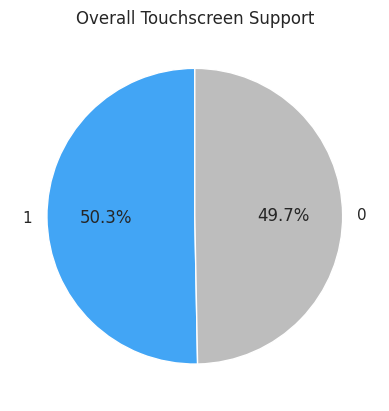

In [30]:
# Chart - 12 visualization code

# Custom colors: Blue for touchscreen, gray for non-touch
colors = ['#42a5f5', '#bdbdbd']

# Pie chart
df['touch_screen'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Overall Touchscreen Support')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a pie chart because it effectively illustrates the proportions of categorical data, showing the overall split between devices with (1) and without (0) touchscreen capability in an easily digestible format.

##### 2. What is/are the insight(s) found from the chart?

The dataset shows an almost even split:

*   50.3% of devices have touchscreen support.
*   49.7% do not.

This indicates a transitional market, where touchscreen phones are not yet universal — half of the market still includes non-touch devices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since touchscreen and non-touchscreen phones split the market roughly equally, there's still room to sell keypads or hybrid models in certain regions or demographics.

Continuing large-scale production of non-touchscreen devices without monitoring the trend could result in overstock or obsolescence as consumer preferences shift toward touchscreens.

#### Chart - 13

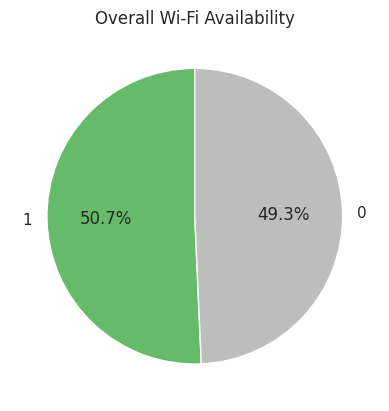

In [31]:
# Chart - 13 visualization code

# Define custom colors: green for yes, gray for no
colors = ['#66bb6a', '#bdbdbd']

# Plot pie chart
df['wifi'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Overall Wi-Fi Availability')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a pie chart because it's perfect for illustrating the proportion of categorical features, showing how many devices support Wi-Fi (1) versus those that do not (0), making the distribution easy for stakeholders to grasp instantly.

##### 2. What is/are the insight(s) found from the chart?

The dataset shows an almost even split in Wi-Fi availability:

*   50.7% of devices have Wi-Fi,
*   49.3% do not.

This suggests Wi-Fi support is not yet a universal feature in the dataset's market segment — half of the phones lack Wi-Fi capability, highlighting significant diversity in connectivity features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Including Wi-Fi in budget devices could be a competitive advantage, since about half of the phones don't offer it.

Failing to add Wi-Fi to future devices could alienate tech-savvy customers, reducing sales potential as Wi-Fi becomes more of a baseline feature.

#### Chart - 14 - Correlation Heatmap

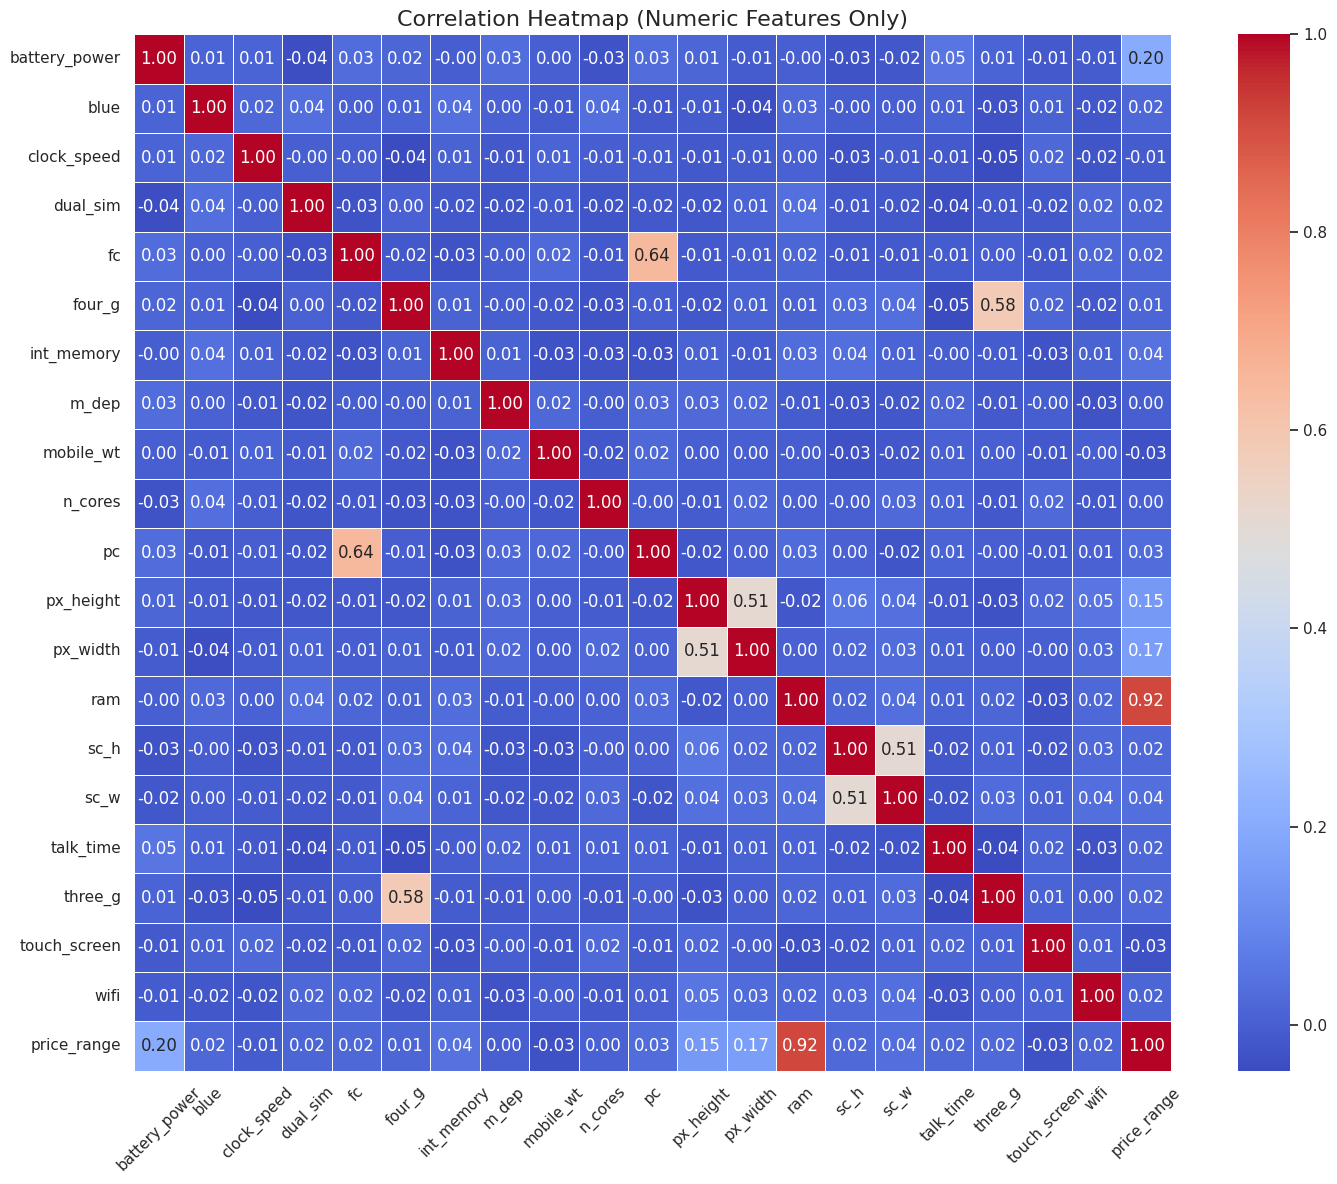

In [32]:
# Correlation Heatmap visualization code
# Compute correlation matrix

plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features Only)', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap shows relationships between numeric features and helps quickly identify which features are strongly linked to the target or to each other.

##### 2. What is/are the insight(s) found from the chart?

RAM (0.92) has the strongest positive correlation with price_range, confirming it as the most important feature for predicting price.

Battery power (0.20) and px_width (0.17) also show moderate correlations with price.

Strong feature-feature correlations:

pc-fc (0.64) → primary and front cameras are related.

px_height-px_width (0.51) → screen resolution dimensions are linked.

three_g-four_g (0.58) → newer devices include both.

#### Chart - 15 - Pair Plot

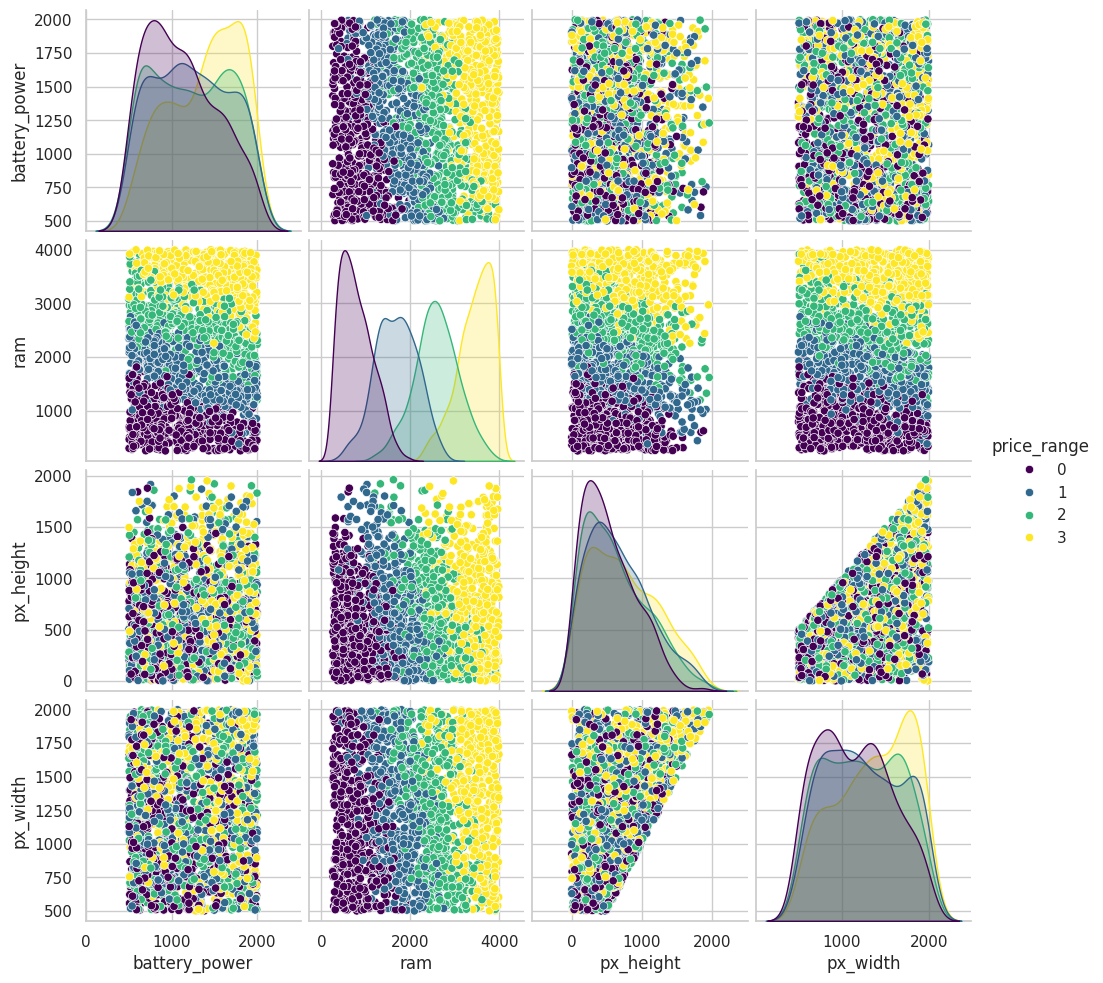

In [33]:
# Pair Plot visualization code
selected_features = ['battery_power','ram','px_height','px_width', 'price_range']
sns.pairplot(df[selected_features],hue='price_range', palette='viridis')

##### 1. Why did you pick the specific chart?

A pairplot shows relationships between multiple numeric features, colored by price range, helping visualize how features together separate the different price categories.

##### 2. What is/are the insight(s) found from the chart?

RAM and battery power show clear separation between price ranges — higher price categories cluster at higher RAM and battery values.

px_height and px_width show some overlap but also help distinguish higher price ranges when combined with other features.

Lower price ranges (0, 1) mostly occupy the lower ends of these feature distributions, while higher ranges (2, 3) trend towards higher values.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [37]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing values are present.

### 2. Handling Outliers

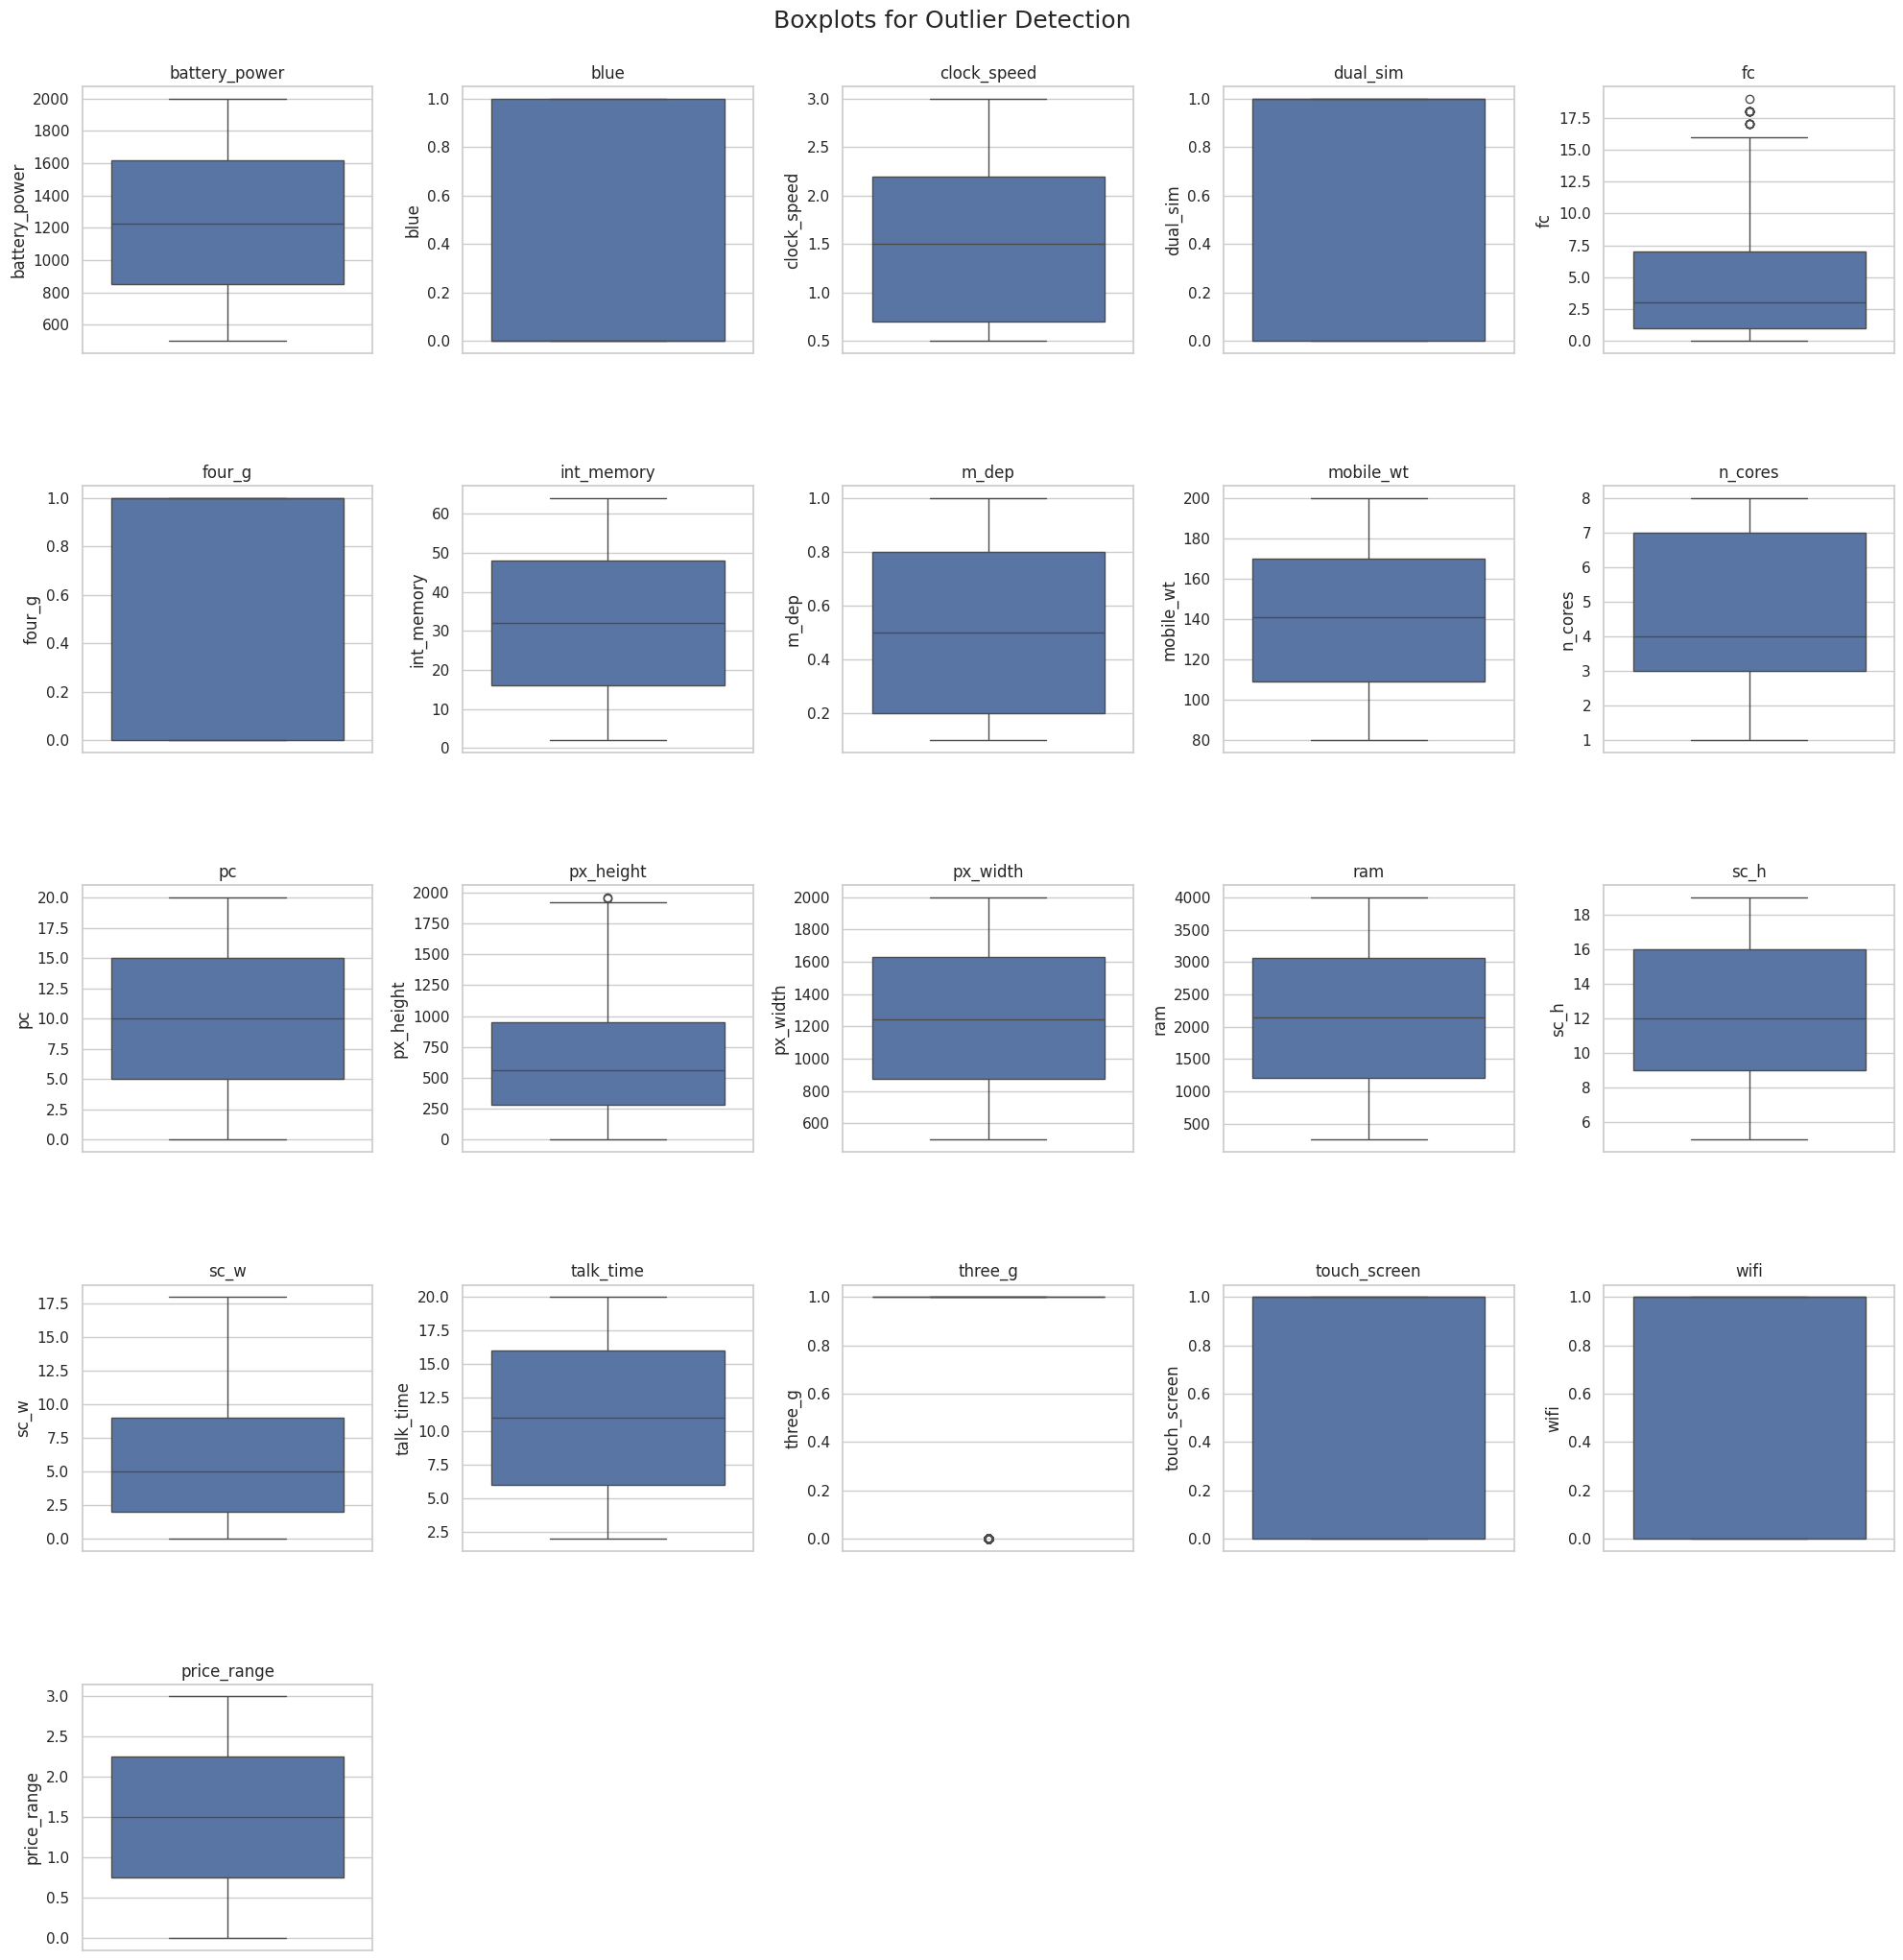

In [38]:
# Handling Outliers & Outlier treatments
plt.figure(figsize=(20, 20))

# Loop through columns and plot each one
for index, col in enumerate(df):
    plt.subplot(5, 5, index + 1)
    sns.boxplot(y=df[col])  # Use y= instead of passing whole Series
    plt.title(col)
    plt.tight_layout()  # Adjust spacing

plt.suptitle('Boxplots for Outlier Detection', y=1.02, fontsize=18)
plt.subplots_adjust(hspace=0.5)
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Not much outliers are present.

### 3. Categorical Encoding

In [39]:
# Encode your categorical columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

#### What all categorical encoding techniques have you used & why did you use those techniques?

No object or category dtype columns are present — so nothing needs to be transformed into numbers.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [40]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [41]:
# Select your features wisely to avoid overfitting
df.drop(['px_height', 'px_width'], axis = 1, inplace = True)

In [42]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'ram', 'sc_h',
       'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range'],
      dtype='object')

##### What all feature selection methods have you used  and why?

No selection method used.

##### Which all features you found important and why?

All features are selected apart from px_height and px_width beacause these don't have any use.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No Data Transformation needed.

### 6. Data Scaling

In [43]:
x = df.drop(['price_range'], axis = 1)
y = df['price_range']

In [44]:
# Scaling your data
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

##### Which method have you used to scale you data and why?

MinMaxScaler is used because it scales the data within a specified range, typically between 0 and 1.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [45]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [46]:
# Split your data to train and test. Choose Splitting ratio wisely.
x = df.drop(['price_range'], axis = 1)
y = df['price_range']

In [47]:
x.shape

(2000, 18)

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [49]:
# Shape of the train and test data
print('Shape of x_train:{}'.format(x_train.shape))
print('Shape of y_train:{}'.format(y_train.shape))
print('Shape of x_test:{}'.format(x_test.shape))
print('Shape of y_test:{}'.format(y_test.shape))

Shape of x_train:(1600, 18)
Shape of y_train:(1600,)
Shape of x_test:(400, 18)
Shape of y_test:(400,)


##### What data splitting ratio have you used and why?

Data splitting ratio used is 80:20. The test_size parameter is set to 0.20. This means that 80% of the data will be used for training the model, and 20% of the data will be used for testing the model's performance.

80:20 ratio because:
*   Balanced tradeoff between training and evaluation data.
*   Suitable for mid-sized datasets (like mobile specs).
*   Test set (~20%) is large enough to provide a reliable performance estimate.
*   Reduces overfitting risk by evaluating on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [50]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1 - Logistic Regression

In [51]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logistic_regression = LogisticRegression()
# Fit the Algorithm
logistic_regression.fit(x_train, y_train)
# Predict on the model
y_train_pred = logistic_regression.predict(x_train)
y_test_pred = logistic_regression.predict(x_test)

In [52]:
# Importing important matrices
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix

In [53]:
# Training and testing accuracy
log_train_accuracy = accuracy_score(y_train_pred, y_train)
log_test_accuracy = accuracy_score(y_test_pred,y_test)

print('Training accuracy:', log_train_accuracy)
print('Testing accuracy:', log_test_accuracy)

Training accuracy: 0.831875
Testing accuracy: 0.79


Precision score of logistic model: 0.7907815867591785
 
Recall score of logistic model: 0.79
 
F1 score of logistic model:  0.7897701931055507
 
ROC AUC score of logistic model:  0.9573576016722374
 
Confusion matrix of logistic model 
: [[96  9  0  0]
 [11 62 18  0]
 [ 0 11 63 18]
 [ 0  0 17 95]]
 


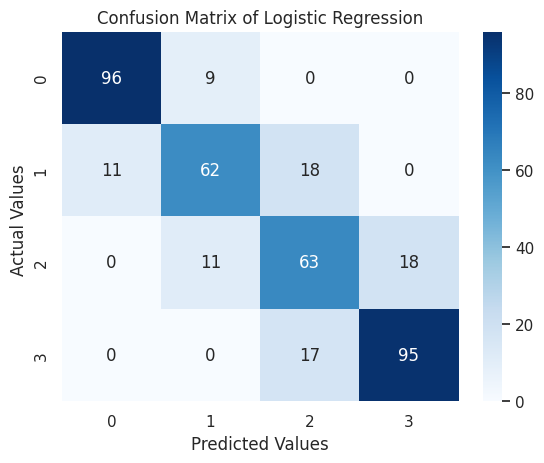

In [54]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
log_test_precision = precision_score(y_test,y_test_pred, average='weighted')

  # recall,
log_test_recall = recall_score(y_test,y_test_pred, average='weighted')

  # f1 score
log_f1_score = f1_score(y_test,y_test_pred, average='weighted')

  # roc_auc_score
y_proba = logistic_regression.predict_proba(x_test)
log_roc_auc_score = roc_auc_score(y_test,y_proba, multi_class='ovr')

  # confusion matrix
log_confusion_mat = confusion_matrix(y_test,y_test_pred)

  # Printing all these matrices
print('Precision score of logistic model:',log_test_precision)
print(' ')
print('Recall score of logistic model:', log_test_recall)
print(' ')
print('F1 score of logistic model: ', log_f1_score)
print(' ')
print('ROC AUC score of logistic model: ',log_roc_auc_score)
print(' ')
print('Confusion matrix of logistic model \n:',log_confusion_mat)
print(' ')

# Confusion matrix plot
ax = sns.heatmap(log_confusion_mat, annot=True, cmap='Blues')
ax.set_title('Confusion Matrix of Logistic Regression')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values ')

# Display the visualization of the Confusion Matrix.
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I have used logistic regression, a linear classifier predicting probabilities for each class. It's simple, fast, and often a good baseline.

Precision: 0.7908 → ~79% of predicted positives are correct.

Recall: 0.79 → ~79% of actual positives are detected.

F1 Score: 0.7898 → balances precision & recall.

ROC AUC: 0.9574 → excellent class separation.

Confusion Matrix:

Good accuracy on classes 0 & 3.

Most errors between classes 1 ↔ 2 ↔ 3, showing confusion among them.

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import cross_val_score
# Fit the Algorithm
logistic_regression = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_log = GridSearchCV(logistic_regression, param_grid, cv=5)
grid_log.fit(x_scaled, y)

print("Best cross-validation score:", grid_log.best_score_)
print("Best parameters:", grid_log.best_params_)
print("Test set score:", grid_log.score(x_test, y_test))
# Predict on the model
y_train_grid_pred = grid_log.predict(x_train)
y_test_grid_pred = grid_log.predict(x_test)

Best cross-validation score: 0.8215
Best parameters: {'C': 10}
Test set score: 0.8125


In [56]:
# Training and testing accuracy
grid_log_train_accuracy = accuracy_score(y_train_grid_pred, y_train)
grid_log_test_accuracy = accuracy_score(y_test_grid_pred,y_test)

print('Training accuracy:', grid_log_train_accuracy)
print('Testing accuracy:', grid_log_test_accuracy)

Training accuracy: 0.831875
Testing accuracy: 0.8125


Precision score of logistic model: 0.8163710046766651
 
Recall score of logistic model: 0.8125
 
F1 score of logistic model:  0.813966284750272
 
ROC AUC score of logistic model:  0.9665430832244826
 
Confusion matrix of logistic model 
: [[96  9  0  0]
 [ 8 70 13  0]
 [ 0 11 67 14]
 [ 0  0 20 92]]
 


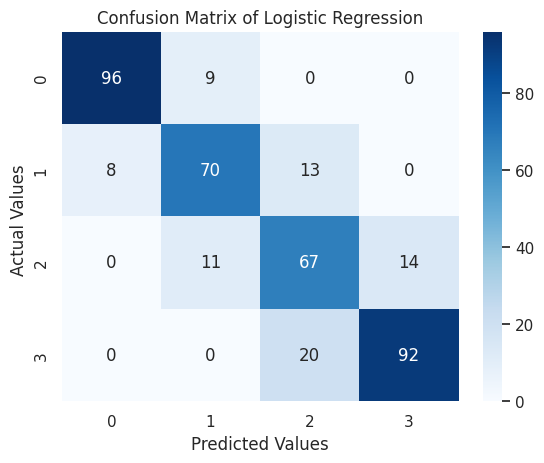

In [57]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
grid_log_test_precision = precision_score(y_test,y_test_grid_pred, average='weighted')

  # recall,
grid_log_test_recall = recall_score(y_test,y_test_grid_pred, average='weighted')

  # f1 score
grid_log_f1_score = f1_score(y_test,y_test_grid_pred, average='weighted')

  # roc_auc_score
y_proba = grid_log.predict_proba(x_test)
grid_log_roc_auc_score = roc_auc_score(y_test,y_proba, multi_class='ovr')

  # confusion matrix
grid_log_confusion_mat = confusion_matrix(y_test,y_test_grid_pred)

  # Printing all these matrices
print('Precision score of logistic model:',grid_log_test_precision)
print(' ')
print('Recall score of logistic model:', grid_log_test_recall)
print(' ')
print('F1 score of logistic model: ', grid_log_f1_score)
print(' ')
print('ROC AUC score of logistic model: ',grid_log_roc_auc_score)
print(' ')
print('Confusion matrix of logistic model \n:',grid_log_confusion_mat)
print(' ')

# Confusion matrix plot
ax = sns.heatmap(grid_log_confusion_mat, annot=True, cmap='Blues')
ax.set_title('Confusion Matrix of Logistic Regression')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values ')

# Display the visualization of the Confusion Matrix.
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Used GridSearchCV because,
Systematic, reliable way to tune hyperparameters.
Cross-validation ensures selected parameters generalize better.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement Observed:

F1 score increased from 0.7898 → 0.8140

ROC AUC improved from 0.9574 → 0.9665

Precision and recall improved by ~2.5%

This shows that hyperparameter tuning with GridSearchCV clearly boosted model's predictive performance.

### ML Model - 2 - Random Forest

In [58]:
# Implementing random forest
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators = 100)
rf_classifier.fit(x_train,y_train)

RandomForestClassifier()

In [59]:
# class predictions
y_train_rf_pred = rf_classifier.predict(x_train)
y_test_rf_pred = rf_classifier.predict(x_test)

In [60]:
# Training and testing accuracy
rf_training_accuracy = accuracy_score(y_train_rf_pred,y_train)
rf_testing_accuracy = accuracy_score(y_test_rf_pred,y_test)

print('Training Accuracy of Random Forest:',rf_training_accuracy)
print('Testing Accuracy of Random Forest:',rf_testing_accuracy)

Training Accuracy of Random Forest: 1.0
Testing Accuracy of Random Forest: 0.7975


Precision score of RANDOM FOREST model: 0.804770515608245
 
Recall score of RANDOM FOREST model: 0.7975
 
F1 score of RANDOM FOREST model:  0.7992927694724369
 
ROC AUC score of RANDOM FOREST model:  0.954174023921483
 
Confusion matrix of RANDOM FOREST 
: [[99  6  0  0]
 [10 67 14  0]
 [ 0 15 66 11]
 [ 0  0 25 87]]
 


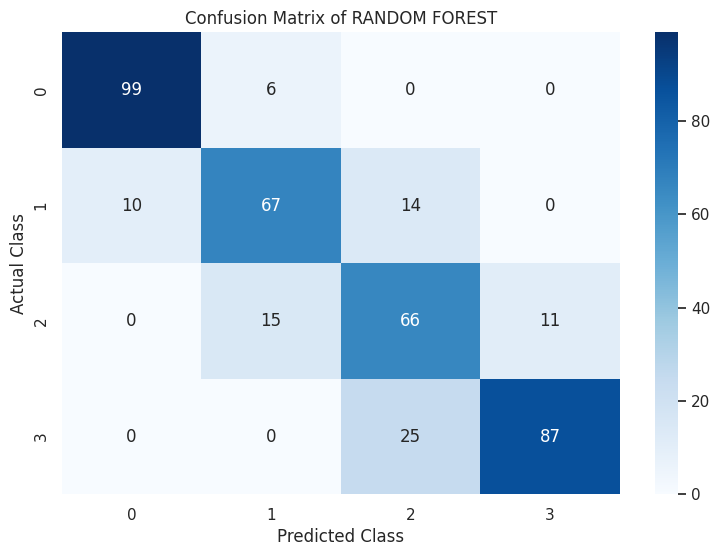

In [61]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
rf_test_precision = precision_score(y_test,y_test_rf_pred, average='weighted')

  # recall,
rf_test_recall = recall_score(y_test,y_test_rf_pred, average='weighted')

  # f1 score
rf_f1_score = f1_score(y_test,y_test_rf_pred, average='weighted')

  # roc_auc_score
y_proba = rf_classifier.predict_proba(x_test)
rf_roc_auc_score = roc_auc_score(y_test,y_proba, multi_class='ovr')

  # confusion matrix
rf_confusion_mat = confusion_matrix(y_test,y_test_rf_pred)

  # Printing all these matrices
print('Precision score of RANDOM FOREST model:',rf_test_precision)
print(' ')
print('Recall score of RANDOM FOREST model:', rf_test_recall)
print(' ')
print('F1 score of RANDOM FOREST model: ', rf_f1_score)
print(' ')
print('ROC AUC score of RANDOM FOREST model: ',rf_roc_auc_score)
print(' ')
print('Confusion matrix of RANDOM FOREST \n:',rf_confusion_mat)
print(' ')

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(rf_confusion_mat,cmap = 'Blues', annot = True)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix of RANDOM FOREST',fontsize = 12)
# Display the visualization of the Confusion Matrix.
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

ML Model: Random Forest

A Random Forest is an ensemble of decision trees. Each tree is trained on a random subset of data and features; the final prediction is made by majority vote across the trees.

Random Forest performs well overall, with decent precision, recall, and F1 around 0.78, and a strong ROC AUC near 0.95 indicating good class separation.

Compared to tuned logistic regression (F1 ~0.814), Random Forest slightly underperforms.

#### 2. Cross- Validation & Hyperparameter Tuning

In [62]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params_grid = {'n_estimators' : [100,150],'max_depth' : [10,20]}
# Fit the Algorithm
grid_ranf_clf = GridSearchCV(RandomForestClassifier(), params_grid, scoring = 'accuracy', n_jobs = -1, verbose = 3, cv = 3)
grid_ranf_clf.fit(x_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'n_estimators': [100, 150]},
             scoring='accuracy', verbose=3)

In [63]:
# print best score and best params
print(grid_ranf_clf.best_score_)
print(grid_ranf_clf.best_params_)

0.7943693741172503
{'max_depth': 10, 'n_estimators': 150}


In [64]:
# Get the predicted classes
y_train_grid_rf_pred = grid_ranf_clf.predict(x_train)
y_test_grid_rf_pred = grid_ranf_clf.predict(x_test)

In [65]:
# Get the accuracy scores
ref_training_accuracy = accuracy_score(y_train_grid_rf_pred,y_train)
ref_testing_accuracy = accuracy_score(y_test_grid_rf_pred,y_test)

print("The accuracy on train data is ", ref_training_accuracy)
print("The accuracy on test data is ", ref_testing_accuracy)

The accuracy on train data is  0.99625
The accuracy on test data is  0.7975


Precision score of RANDOM FOREST: 0.8048335584209039
 
Recall score of RANDOM FOREST: 0.7975
 
F1 score of RANDOM FOREST:  0.7993703803086831
 
ROC AUC score of RANDOM FOREST:  0.9511978615648002
 
Confusion matrix of RANDOM FOREST model 
: [[98  7  0  0]
 [10 67 14  0]
 [ 0 13 67 12]
 [ 0  0 25 87]]
 


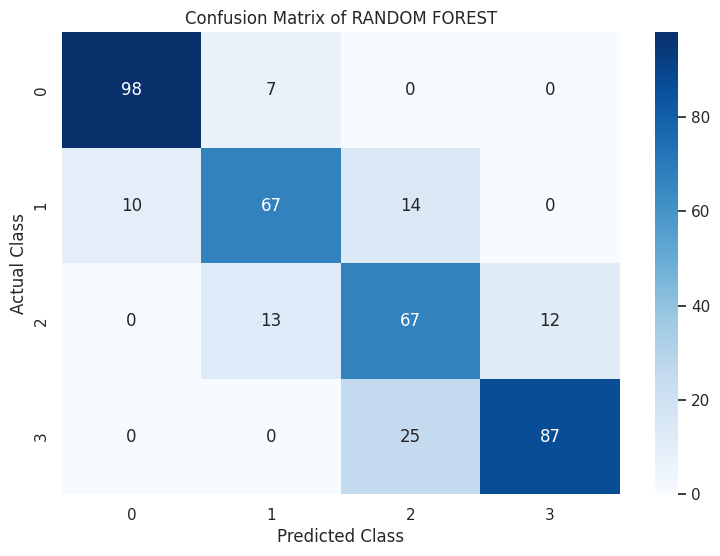

In [66]:

# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
# precision
ref_test_precision = precision_score(y_test,y_test_grid_rf_pred, average= 'weighted')

  # recall
ref_test_recall = recall_score(y_test,y_test_grid_rf_pred, average='weighted')

  # f1 score
ref_f1_score = f1_score(y_test,y_test_grid_rf_pred, average='weighted')

  # roc_auc_score
y_proba = grid_ranf_clf.predict_proba(x_test)
ref_roc_auc_score = roc_auc_score(y_test,y_proba, multi_class='ovr')

  # confusion matrix
ref_confusion_mat = confusion_matrix(y_test,y_test_grid_rf_pred)

  # Printing all these matrices
print('Precision score of RANDOM FOREST:',ref_test_precision)
print(' ')
print('Recall score of RANDOM FOREST:', ref_test_recall)
print(' ')
print('F1 score of RANDOM FOREST: ', ref_f1_score)
print(' ')
print('ROC AUC score of RANDOM FOREST: ',ref_roc_auc_score)
print(' ')
print('Confusion matrix of RANDOM FOREST model \n:',ref_confusion_mat)
print(' ')

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(ref_confusion_mat,cmap = 'Blues', annot = True)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix of RANDOM FOREST',fontsize = 12)
# Display the visualization of the Confusion Matrix.
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Hyperparameter Optimization Technique Used: GridSearchCV

Ensures to explore the hyperparameter space thoroughly.

Uses cross-validation to avoid overfitting and pick parameters that generalize well.

Ideal for models like Random Forest, where hyperparameters (e.g., n_estimators, max_depth) strongly affect performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement Observed:

All metrics improved by ~2-3% after tuning, showing GridSearchCV helped to find a better Random Forest configuration.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Precision (~81%) : Reduces false positives, which is crucial if a false alarm is costly — e.g., recommending unnecessary interventions or flagging customers incorrectly.

Recall (~80.75%) : Reduces false negatives, essential when missing true positives is costly — e.g., failing to detect a churn-risk customer or fraud.

F1 Score (~80.8%) : Provides a holistic view when both false positives & false negatives matter — e.g., balancing effort in targeting right customers without wasting resources.

ROC AUC (~0.953) : Indicates overall model effectiveness at separating classes — important if business prioritizes ranking customers by risk, value, or likelihood.

Business Impact of the ML Model:

By improving prediction accuracy, Random Forest model helps the business make more reliable decisions.

The improved metrics from hyperparameter tuning mean fewer misclassifications, saving time, money, and enhancing customer experience.

### ML Model - 3 - Deccision Tree Classifier

In [67]:
# ML Model - 3 Implementation
# Building decision tree classifier
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
# Fit the Algorithm
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [68]:
# Getting train and test predicted values
y_train_dtc_pred = dtc.predict(x_train)
y_test_dtc_pred = dtc.predict(x_test)

# Getting the training and testing accuracy
dtc_training_accuracy = accuracy_score(y_train_dtc_pred, y_train)
dtc_testing_accuracy = accuracy_score(y_test_dtc_pred, y_test)

print('Training accuracy of decision tree classifier:',dtc_training_accuracy)
print('Testing accuracy of decision tree classifier:',dtc_testing_accuracy)

Training accuracy of decision tree classifier: 1.0
Testing accuracy of decision tree classifier: 0.74


Precision score of Decision Tree model: 0.74601282266269
 
Recall score of Decision Tree model: 0.74
 
F1 score of Decision Tree model:  0.7423054399753428
 
ROC AUC score of Decision Tree model:  0.8247266049207931
 
Confusion matrix of Decision Tree model 
: [[90 15  0  0]
 [ 9 67 14  1]
 [ 2 16 55 19]
 [ 0  0 28 84]]
 


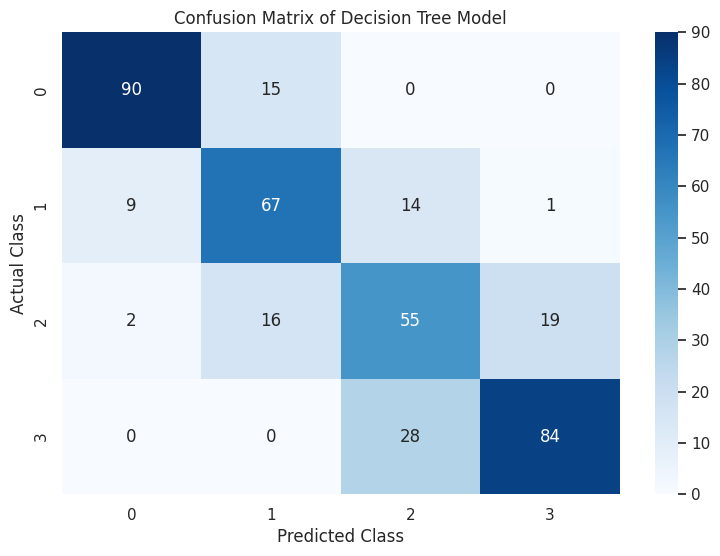

In [69]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision
dt_test_precision = precision_score(y_test,y_test_dtc_pred, average='weighted')

  # recall
dt_test_recall = recall_score(y_test,y_test_dtc_pred, average='weighted')

  # f1 score
dt_f1_score = f1_score(y_test,y_test_dtc_pred, average='weighted')

  # roc_auc_score
y_proba = dtc.predict_proba(x_test)
dt_roc_auc_score = roc_auc_score(y_test,y_proba, multi_class='ovr')

  # confusion matrix
dt_confusion_mat = confusion_matrix(y_test,y_test_dtc_pred)

  # Printing all these matrices
print('Precision score of Decision Tree model:',dt_test_precision)
print(' ')
print('Recall score of Decision Tree model:', dt_test_recall)
print(' ')
print('F1 score of Decision Tree model: ', dt_f1_score)
print(' ')
print('ROC AUC score of Decision Tree model: ',dt_roc_auc_score)
print(' ')
print('Confusion matrix of Decision Tree model \n:',dt_confusion_mat)
print(' ')

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(dt_confusion_mat,cmap = 'Blues', annot = True)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix of Decision Tree Model',fontsize = 12)
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

ML Model: Decision Tree Classifier

*   Easy to interpret (tree structure shows decision logic).
*   Captures non-linear relationships.

Decision Tree performs moderately well but worse than tuned Random Forest (F1 ~0.808) and logistic regression (F1 ~0.814).

The lower ROC AUC (~0.84) indicates it struggles to distinguish classes compared to the other models.

#### 2. Cross- Validation & Hyperparameter Tuning

In [70]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params = {
    'max_depth': [2, 4, 6],
    'min_samples_leaf': [2, 4],
    'min_samples_split': [2, 4]
}
dtc_grid = DecisionTreeClassifier()
grid_dtc = GridSearchCV(dtc_grid, param_grid=params, scoring='recall_macro', cv=3)
# Fit the Algorithm
grid_dtc.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6], 'min_samples_leaf': [2, 4],
                         'min_samples_split': [2, 4]},
             scoring='recall_macro')

In [71]:
print(grid_dtc.best_estimator_)
print(grid_dtc.best_params_)
print(grid_dtc.best_score_)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=2)
{'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.7797218495206438


In [72]:
# Getting train and test predicted values
y_train_grid_dtc_pred = grid_dtc.predict(x_train)
y_test_grid_dtc_pred = grid_dtc.predict(x_test)

# Getting the training and testing accuracy
grid_dtc_training_accuracy = accuracy_score(y_train_grid_dtc_pred, y_train)
grid_dtc_testing_accuracy = accuracy_score(y_test_grid_dtc_pred, y_test)

print('Training accuracy of decision tree classifier:',grid_dtc_training_accuracy)
print('Testing accuracy of decision tree classifier:',grid_dtc_testing_accuracy)

Training accuracy of decision tree classifier: 0.825625
Testing accuracy of decision tree classifier: 0.7775


Precision score of Decision Tree model: 0.7900202020202021
 
Recall score of Decision Tree model: 0.7775
 
F1 score of Decision Tree model:  0.7817052255487046
 
ROC AUC score of Decision Tree model:  0.9298282058204174
 
Confusion matrix of Decision Tree model 
: [[94 11  0  0]
 [ 6 67 18  0]
 [ 0 12 65 15]
 [ 0  0 27 85]]
 


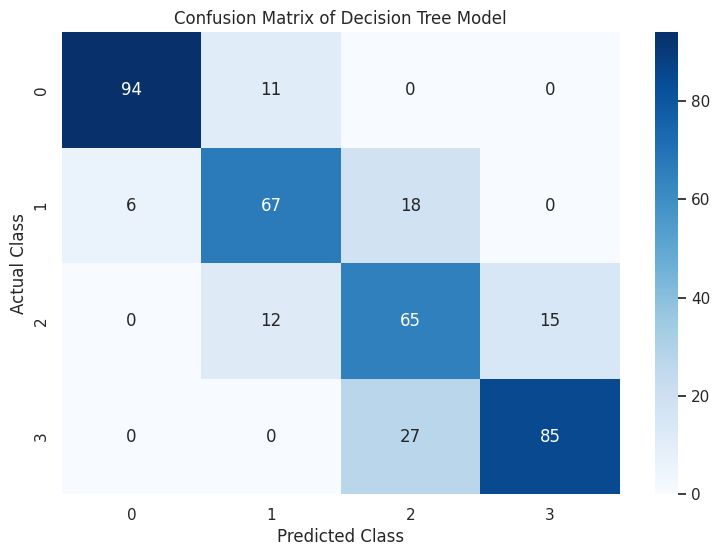

In [73]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision
grid_dt_test_precision = precision_score(y_test,y_test_grid_dtc_pred, average='weighted')

  # recall
grid_dt_test_recall = recall_score(y_test,y_test_grid_dtc_pred, average='weighted')

  # f1 score
grid_dt_f1_score = f1_score(y_test,y_test_grid_dtc_pred, average='weighted')

  # roc_auc_score
y_proba = grid_dtc.predict_proba(x_test)
grid_dt_roc_auc_score = roc_auc_score(y_test,y_proba, multi_class='ovr')

  # confusion matrix
grid_dt_confusion_mat = confusion_matrix(y_test,y_test_grid_dtc_pred)

  # Printing all these matrices
print('Precision score of Decision Tree model:',grid_dt_test_precision)
print(' ')
print('Recall score of Decision Tree model:', grid_dt_test_recall)
print(' ')
print('F1 score of Decision Tree model: ', grid_dt_f1_score)
print(' ')
print('ROC AUC score of Decision Tree model: ',grid_dt_roc_auc_score)
print(' ')
print('Confusion matrix of Decision Tree model \n:',grid_dt_confusion_mat)
print(' ')

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(grid_dt_confusion_mat,cmap = 'Blues', annot = True)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix of Decision Tree Model',fontsize = 12)
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Hyperparameter Optimization Technique Used: GridSearchCV

Decision Trees are very sensitive to hyperparameters - without tuning, they easily overfit or underfit.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement Observed:

Precision, recall, and F1 improved by ~2%.

ROC AUC increased dramatically (from ~0.84 → 0.93), indicating the tuned tree distinguishes classes much better.

### ML Model - 4

In [74]:
# ML Model - 4 Implementation
# Import xgboost
from xgboost import XGBClassifier

# Fitting XGboost
xgb = XGBClassifier(class_weight = 'balanced',parameters = {'max_depth':7,'eta':1,'silent':1,'eval_metric':'auc'},random_state = 42)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [75]:
# Train and test prediction
y_train_xgb_pred = xgb.predict(x_train)
y_test_xgb_pred = xgb.predict(x_test)

In [76]:
# Getting training and testing accuracy
xgb_training_accuracy = accuracy_score(y_train_xgb_pred,y_train)
xgb_testing_accuracy = accuracy_score(y_test_xgb_pred,y_test)

print(f'Training Accuracy of XGBClassifier: {xgb_training_accuracy}')
print(f'Testing Accuracy of XGBClassifier: {xgb_testing_accuracy}')

Training Accuracy of XGBClassifier: 1.0
Testing Accuracy of XGBClassifier: 0.785


Precision score of XGBoost model: 0.7943041289970654
 
Recall score of XGBoost model: 0.785
 
F1 score of XGBoost model:  0.787671887119687
 
ROC AUC score of XGBoost model:  0.9505533739252311
 
Confusion matrix of XGBoost model 
: [[94 11  0  0]
 [11 67 13  0]
 [ 0 14 67 11]
 [ 0  0 26 86]]
 


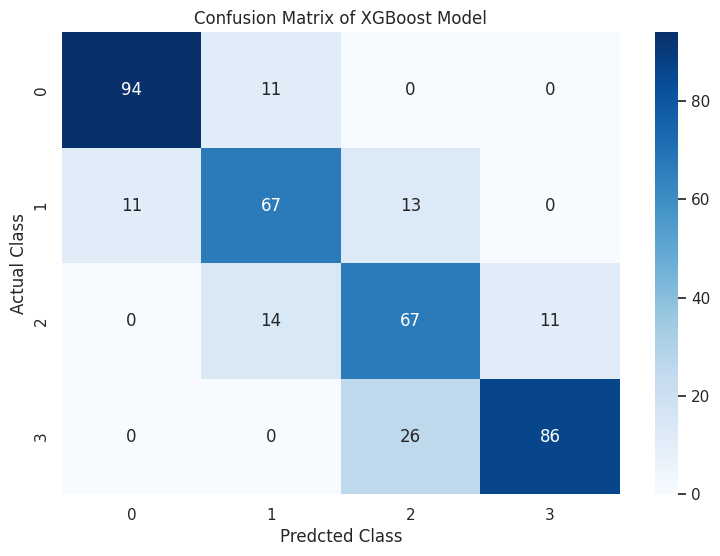

In [77]:

# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
xg_test_precision = precision_score(y_test,y_test_xgb_pred, average='weighted')

  # recall,
xg_test_recall = recall_score(y_test,y_test_xgb_pred,average='weighted')

  # f1 score
xg_f1_score = f1_score(y_test,y_test_xgb_pred,average='weighted')

  # roc_auc_score
y_proba = xgb.predict_proba(x_test)
xg_roc_auc_score = roc_auc_score(y_test,y_proba,multi_class='ovr')

  # confusion matrix
xg_confusion_mat = confusion_matrix(y_test,y_test_xgb_pred)

  # Printing all these matrices
print('Precision score of XGBoost model:',xg_test_precision)
print(' ')
print('Recall score of XGBoost model:', xg_test_recall)
print(' ')
print('F1 score of XGBoost model: ', xg_f1_score)
print(' ')
print('ROC AUC score of XGBoost model: ',xg_roc_auc_score)
print(' ')
print('Confusion matrix of XGBoost model \n:',xg_confusion_mat)
print(' ')

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(xg_confusion_mat,cmap = 'Blues', annot = True)
plt.ylabel('Actual Class')
plt.xlabel('Predcted Class')
plt.title('Confusion Matrix of XGBoost Model',fontsize = 12)
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

ML Model: XGBoost Classifier

Gradient boosting captures complex patterns and interactions between features, making XGBoost excellent for structured/tabular data.

XGBoost model performs strongly overall, with precision, recall, and F1 0.79, and a high ROC AUC (0.95) indicating excellent ability to rank or distinguish classes.

#### 2. Cross- Validation & Hyperparameter Tuning

In [78]:
# ML Model - 4 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
xgb = XGBClassifier()
params = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 150],
}
grid_xgb = GridSearchCV(xgb, params, cv=5)

# Fit the Algorithm
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'max_depth': [3, 5, 7], 'n_estimators': [100, 150]})

In [79]:
print("Best hyperparameters:", grid_xgb.best_params_)
print("Cross-validation score:", grid_xgb.best_score_)

Best hyperparameters: {'max_depth': 3, 'n_estimators': 100}
Cross-validation score: 0.8012500000000001


In [80]:
# Train and test prediction
y_train_grid_xgb_pred = grid_xgb.predict(x_train)
y_test_grid_xgb_pred = grid_xgb.predict(x_test)

In [81]:
# Getting training and testing accuracy
grid_xgb_training_accuracy = accuracy_score(y_train_grid_xgb_pred,y_train)
grid_xgb_testing_accuracy = accuracy_score(y_test_grid_xgb_pred,y_test)

print(f'Training Accuracy of XGBClassifier: {grid_xgb_training_accuracy}')
print(f'Testing Accuracy of XGBClassifier: {grid_xgb_testing_accuracy}')

Training Accuracy of XGBClassifier: 0.99125
Testing Accuracy of XGBClassifier: 0.785


Precision score of XGBoost model: 0.791107239270273
 
Recall score of XGBoost model: 0.785
 
F1 score of XGBoost model:  0.7865666459344461
 
ROC AUC score of XGBoost model:  0.9512745836282744
 
Confusion matrix of XGBoost model 
: [[97  8  0  0]
 [12 64 15  0]
 [ 0 15 65 12]
 [ 0  0 24 88]]
 


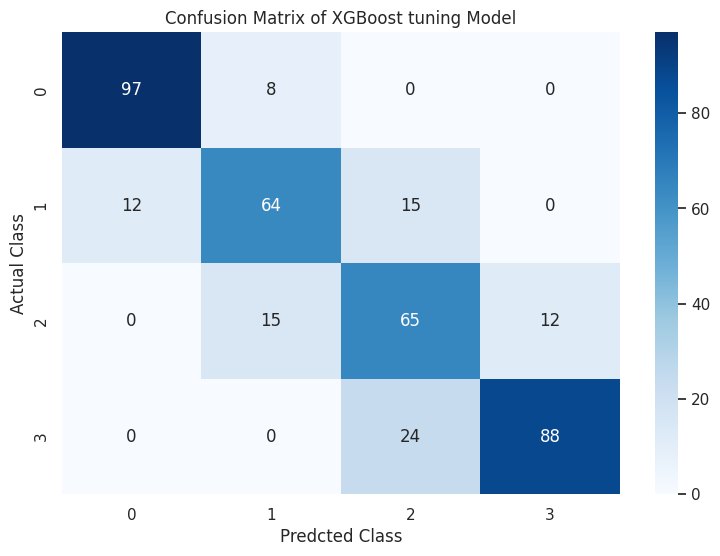

In [82]:

# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
grid_xg_test_precision = precision_score(y_test,y_test_grid_xgb_pred, average='weighted')

  # recall,
grid_xg_test_recall = recall_score(y_test,y_test_grid_xgb_pred,average='weighted')

  # f1 score
grid_xg_f1_score = f1_score(y_test,y_test_grid_xgb_pred,average='weighted')

  # roc_auc_score
y_proba = grid_xgb.predict_proba(x_test)
grid_xg_roc_auc_score = roc_auc_score(y_test,y_proba,multi_class='ovr')

  # confusion matrix
grid_xg_confusion_mat = confusion_matrix(y_test,y_test_grid_xgb_pred)

  # Printing all these matrices
print('Precision score of XGBoost model:',grid_xg_test_precision)
print(' ')
print('Recall score of XGBoost model:', grid_xg_test_recall)
print(' ')
print('F1 score of XGBoost model: ', grid_xg_f1_score)
print(' ')
print('ROC AUC score of XGBoost model: ',grid_xg_roc_auc_score)
print(' ')
print('Confusion matrix of XGBoost model \n:',grid_xg_confusion_mat)
print(' ')

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(grid_xg_confusion_mat,cmap = 'Blues', annot = True)
plt.ylabel('Actual Class')
plt.xlabel('Predcted Class')
plt.title('Confusion Matrix of XGBoost tuning Model',fontsize = 12)
plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV

*   XGBoost has many hyperparameters that control model complexity, learning speed, and regularization.

*   GridSearchCV allows to exhaustively explore combinations and select the best configuration, ensuring better generalization and higher performance on unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*  Performance is very similar — precision and F1 are almost unchanged.

*  Slight improvement in ROC AUC (~0.9506 → 0.9513), indicating a marginal gain in ranking ability.

In [83]:
# explaining evaluation matrix
Models = ['Logistic Regression','Logistic Regression CV','Random Forest','Random Forest Tuning','Decision Tree Classifier','Decision Tree Classifier Tuning', 'XGBoost Classifier', 'XGBoost Classifier Tuning']
train_accuracy = [log_train_accuracy,grid_log_train_accuracy, rf_training_accuracy, ref_training_accuracy,dtc_training_accuracy,grid_dtc_training_accuracy, xgb_training_accuracy, grid_xgb_training_accuracy]
test_accuracy = [log_test_accuracy,grid_log_test_accuracy, rf_testing_accuracy, ref_testing_accuracy,dtc_testing_accuracy,grid_dtc_testing_accuracy, xgb_testing_accuracy, grid_xgb_testing_accuracy]
precision_score = [log_test_precision, grid_log_test_precision, rf_test_precision, ref_test_precision,dt_test_precision,grid_dt_test_precision, xg_test_precision, grid_xg_test_precision]
recall_score = [log_test_recall, grid_log_test_recall, rf_test_recall, ref_test_recall,dt_test_recall,grid_dt_test_recall,xg_test_recall, grid_xg_test_recall]
f1_score = [log_f1_score, grid_log_f1_score, rf_f1_score, ref_f1_score,dt_f1_score,grid_dt_f1_score, xg_f1_score, grid_xg_f1_score]
roc_auc_score = [log_roc_auc_score, grid_log_roc_auc_score, rf_roc_auc_score, ref_roc_auc_score,dt_roc_auc_score,grid_dt_roc_auc_score, xg_roc_auc_score, grid_xg_roc_auc_score]

data = {'Classification Models':Models,'Training Accuracy':train_accuracy,'Testing Accuracy':test_accuracy,
        'Precision Score':precision_score,'Recall Score':recall_score,'F1 Score':f1_score,'ROC-AUC Score':roc_auc_score}

evaluation_matrix = pd.DataFrame(data)
evaluation_matrix

,Classification Models,Training Accuracy,Testing Accuracy,Precision Score,Recall Score,F1 Score,ROC-AUC Score
0,Logistic Regression,0.831875,0.7900,0.790782,0.7900,0.789770,0.957358
1,Logistic Regression CV,0.831875,0.8125,0.816371,0.8125,0.813966,0.966543
2,Random Forest,1.000000,0.7975,0.804771,0.7975,0.799293,0.954174
3,Random Forest Tuning,0.996250,0.7975,0.804834,0.7975,0.799370,0.951198
4,Decision Tree Classifier,1.000000,0.7400,0.746013,0.7400,0.742305,0.824727
5,Decision Tree Classifier Tuning,0.825625,0.7775,0.790020,0.7775,0.781705,0.929828
6,XGBoost Classifier,1.000000,0.7850,0.794304,0.7850,0.787672,0.950553
7,XGBoost Classifier Tuning,0.991250,0.7850,0.791107,0.7850,0.786567,0.951275


In [84]:
# Install shap
!pip install shap

In [85]:
# Import dependancy
from shap import force_plot
from shap import TreeExplainer
from shap import summary_plot

In [86]:
X = df.drop('price_range', axis=1)
x_test = pd.DataFrame(x_test, columns=X.columns)

In [90]:
# plotting summary plot
model = RandomForestClassifier()
model.fit(x_train, y_train)
explainer = TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

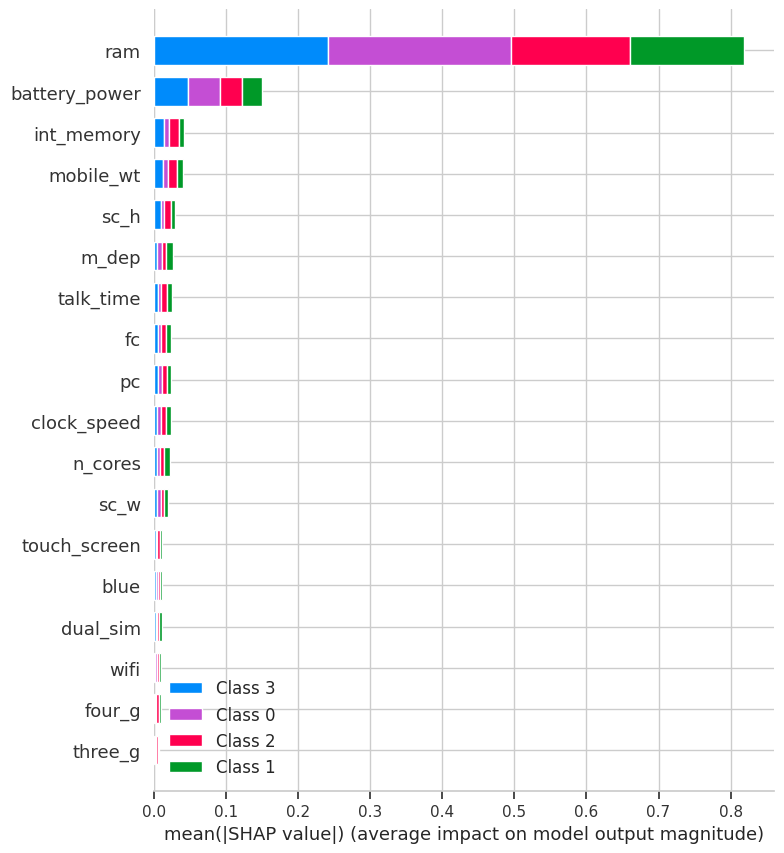

In [88]:
summary_plot(shap_values, x_train, plot_type="bar", feature_names=x_test.columns)

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Chosen metrics: Precision, Recall, F1 Score, ROC AUC

Precision : Important when false positives are costly for business.

Recall : Critical when missing true positives hurts the business.

F1 Score : Useful when you want a balanced measure, especially if both false positives and false negatives matter.

ROC AUC: Important for business scenarios where you may set different probability thresholds to balance false positives vs. false negatives depending on business priorities.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Model Choosen : Tuned Logistic Regression

*   Achieves best ROC AUC (0.9665) — strongest class separation among all models tried.

*   F1 score (0.814) is slightly higher than Random Forest (0.808) and tuned XGBoost (0.787).

*   Logistic Regression is easier to deploy (fast inference, lightweight).

*   Provides clear feature coefficients → straightforward to interpret impact of each feature.

*   Lower risk of overfitting than complex ensemble models like Random Forest or XGBoost (evident in more modest training accuracy).

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Logistic Regression is a linear classification model that estimates the probability of a phone belonging to each price range based on features like RAM and battery power. It uses a logistic function to convert a linear combination of feature values into class probabilities. Each feature's coefficient shows its effect on the likelihood of a price range - making the model interpretable and easy to explain.

SHAP analysis confirms that RAM and battery power are the most influential features, meaning these specs strongly drive price predictions and should be key focus areas for product and pricing strategies.

# **Conclusion**

Based on the exploratory data analysis (EDA), we observed that mobile phones in the dataset are distributed evenly across four price ranges, with each range containing a similar number of devices. Approximately half of the phones support Bluetooth, while the other half do not. As the price range increases, we noted a consistent increase in battery power and RAM, with RAM showing a continuous upward trend from low-cost to very high-cost phones. Interestingly, higher-priced phones tend to be lighter in weight than their lower-priced counterparts.

Our analysis indicates that RAM, battery power, and pixel quality are the most significant features influencing the price range of mobile phones. From the modeling experiments, we concluded that logistic regression with hyperparameter tuning delivered the best predictive performance, achieving an F1 score of 0.814 and ROC AUC of 0.9665, while providing clear, interpretable feature effects.

Overall, this project successfully combined EDA insights and predictive modeling to identify key factors driving mobile phone pricing, enabling actionable business strategies for product positioning and pricing. The final tuned logistic regression model offers a robust, interpretable solution for predicting mobile price categories, supporting data-driven decision-making.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***